In [17]:
# Cell 1: Mount Drive + Setup
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
import warnings
warnings.filterwarnings('ignore')


In [18]:
# Mount Google Drive
drive.mount('/content/drive')

# Check your MITBIH folder structure
mitbih_path = '/content/drive/MyDrive/ECG Dataset/'
print("📁 Checking MITBIH folder...")
print(os.listdir(mitbih_path) if os.path.exists(mitbih_path) else "❌ Path not found! Update mitbih_path")

# Expected files: 48 .mat files (100.mat, 101.mat, etc.)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Checking MITBIH folder...
['mit-bih-arrhythmia-database-1.0.0.zip', 'Segerated datset ', 'MITBIH_extracted', 'mitbih_beat_segments_aami_age_sex.csv', 'streamlit_dashboard.py', 'cnn_mitbih_full.h5', 'ptb-diagnostic-ecg-database-1.0.0.zip', 'label_cnn_mitbih_aami_360.h5', 'mitbih_5records.csv', 'mitbih_raw.csv', 'mitbih_features.csv', 'round2_preprocessing_dashboard.png', 'heartbeats_record100.csv', 'record100_eda.png']


In [19]:
#  Install wfdb (MITBIH official reader)
!pip install wfdb -q
print("✅ wfdb installed!")


✅ wfdb installed!


In [20]:
#  Load MITBIH Record 100 (.dat + .hea format)
import wfdb
import numpy as np
import matplotlib.pyplot as plt

extract_path = '/content/drive/MyDrive/ECG Dataset/MITBIH_extracted/mit-bih-arrhythmia-database-1.0.0/'
record_name = '100'

# Load record using wfdb (MITBIH standard)
record = wfdb.rdrecord(os.path.join(extract_path, record_name))
annotation = wfdb.rdann(os.path.join(extract_path, record_name), 'atr')

print("✅ RECORD LOADED!")
print(f"Signals: {len(record.p_signal)} channels")
print(f"Samples: {len(record.p_signal)} @ {record.fs} Hz")
print(f"Duration: {len(record.p_signal)/record.fs/60:.1f} minutes")
print(f"R-peaks found: {len(annotation.sample)}")
print("\nFirst 5 annotations:", annotation.symbol[:5])
print("ECG Channel 0 (MLII):", record.p_signal[:5, 0])


✅ RECORD LOADED!
Signals: 650000 channels
Samples: 650000 @ 360 Hz
Duration: 30.1 minutes
R-peaks found: 2274

First 5 annotations: ['+', 'N', 'N', 'N', 'N']
ECG Channel 0 (MLII): [-0.145 -0.145 -0.145 -0.145 -0.145]


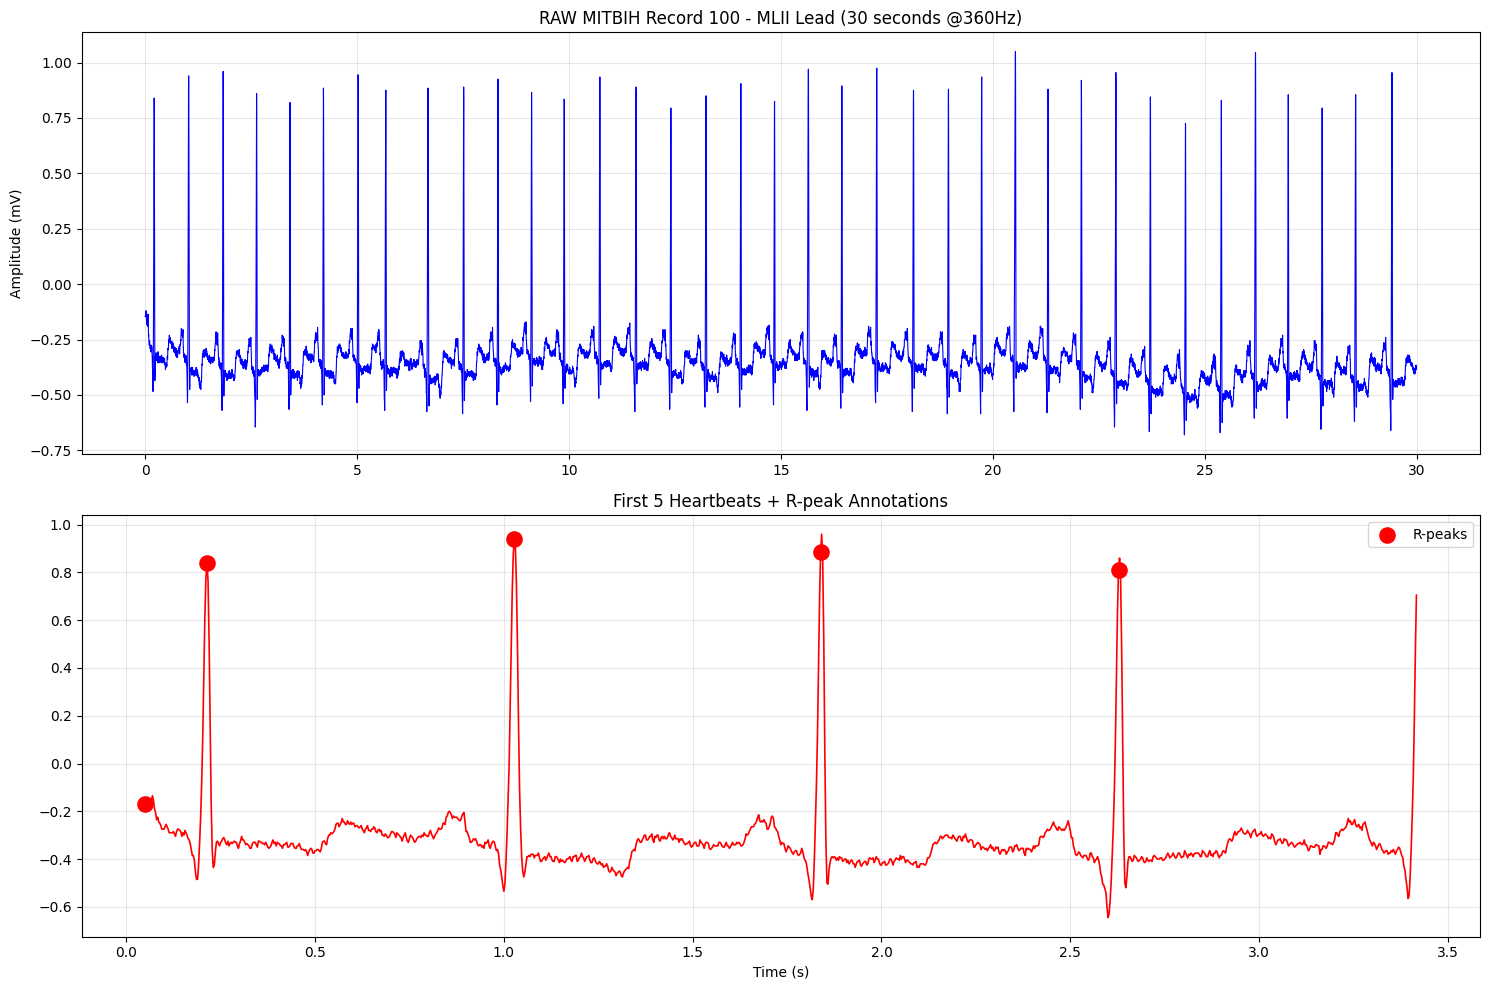

❤️ Average Heart Rate: 74.5 BPM
✅ ECG visualization complete!
Next: Extract 187-sample heartbeats for ML!


In [21]:
#  Plot RAW ECG + R-peaks
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

fs = record.fs  # 360 Hz
ecg = record.p_signal[:, 0]  # MLII lead

# 30 seconds overview
t = np.arange(len(ecg[:30*fs])) / fs
ax1.plot(t, ecg[:30*fs], 'b-', linewidth=0.8)
ax1.set_title('RAW MITBIH Record 100 - MLII Lead (30 seconds @360Hz)')
ax1.set_ylabel('Amplitude (mV)')
ax1.grid(True, alpha=0.3)

# First 10 heartbeats with R-peaks
first_peaks = annotation.sample[:10]
t_zoom = np.arange(first_peaks[0], first_peaks[5]) / fs
ax2.plot(t_zoom, ecg[first_peaks[0]:first_peaks[5]], 'r-', linewidth=1.2)
ax2.scatter(first_peaks[:5]/fs, ecg[first_peaks[:5]], c='red', s=120, zorder=5, label='R-peaks')
ax2.legend()
ax2.set_title('First 5 Heartbeats + R-peak Annotations')
ax2.set_xlabel('Time (s)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"❤️ Average Heart Rate: {60*fs/np.mean(np.diff(annotation.sample[:100])):.1f} BPM")
print("✅ ECG visualization complete!")
print("Next: Extract 187-sample heartbeats for ML!")


In [22]:
# : Extract 187-sample heartbeats (ML READY)
WINDOW_SIZE = 187  # Standard for ECG classification
heartbeats = []
labels = []

print("🔄 Extracting heartbeats from Record 100...")

# MITBIH annotation codes → ML labels
ann_codes = {'N': 0, 'L': 1, 'R': 1, 'e': 1, 'j': 1,  # Normal/Supraventricular
             'V': 2, 'E': 2,  # Ventricular
             'F': 3,         # Fusion
             '/': 4, 'Q': 4, 'f': 4}  # Unknown

for i, (sample, symbol) in enumerate(zip(annotation.sample, annotation.symbol)):
    start = int(sample) - (WINDOW_SIZE//2)
    end = start + WINDOW_SIZE

    # Skip out of bounds
    if start < 0 or end > len(ecg):
        continue

    heartbeat = ecg[start:end]
    heartbeats.append(heartbeat)

    # Map annotation to label
    label = ann_codes.get(symbol, 0)  # Default: Normal
    labels.append(label)

print(f"✅ Extracted {len(heartbeats)} heartbeats")
print(f"Label distribution: {np.bincount(labels)}")
print(f"Shape: {np.array(heartbeats).shape}")

# Save for dashboard
df_beats = pd.DataFrame(heartbeats)
df_beats['label'] = labels
df_beats.to_csv('/content/drive/MyDrive/ECG Dataset/heartbeats_record100.csv', index=False)
print("💾 Saved: heartbeats_record100.csv (187 cols + label)")


🔄 Extracting heartbeats from Record 100...
✅ Extracted 2271 heartbeats
Label distribution: [2270    0    1]
Shape: (2271, 187)
💾 Saved: heartbeats_record100.csv (187 cols + label)


📊 HEARTBEAT EDA:
       0      1      2      3      4      5      6      7      8      9  ...  \
0 -0.315 -0.310 -0.305 -0.305 -0.310 -0.300 -0.305 -0.290 -0.300 -0.300  ...   
1 -0.350 -0.350 -0.340 -0.330 -0.345 -0.345 -0.355 -0.350 -0.340 -0.330  ...   
2 -0.355 -0.355 -0.355 -0.375 -0.385 -0.355 -0.360 -0.355 -0.360 -0.360  ...   
3 -0.380 -0.360 -0.360 -0.345 -0.345 -0.350 -0.355 -0.345 -0.330 -0.330  ...   
4 -0.330 -0.330 -0.330 -0.340 -0.340 -0.340 -0.325 -0.325 -0.325 -0.345  ...   

     178    179    180    181    182    183    184    185    186  label  
0 -0.435 -0.430 -0.430 -0.420 -0.430 -0.450 -0.455 -0.450 -0.435      0  
1 -0.415 -0.420 -0.420 -0.425 -0.415 -0.415 -0.410 -0.435 -0.430      0  
2 -0.390 -0.375 -0.365 -0.385 -0.380 -0.390 -0.375 -0.375 -0.365      0  
3 -0.425 -0.450 -0.445 -0.450 -0.435 -0.445 -0.470 -0.455 -0.460      0  
4 -0.425 -0.425 -0.410 -0.410 -0.420 -0.430 -0.445 -0.440 -0.435      0  

[5 rows x 188 columns]

Label distribution:
label
0    22

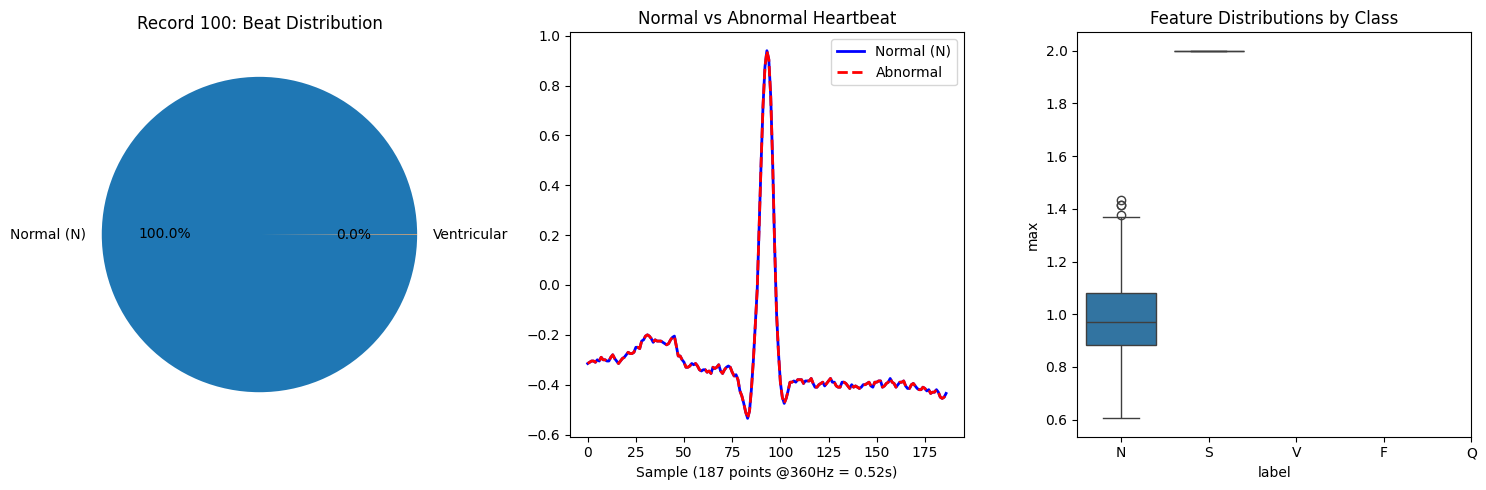

✅ Round 2 Visualization #1 SAVED: record100_eda.png
📈 Features computed: mean, std, min, max


In [23]:
#  EDA + Preprocessing Visualizations (Round 2 READY)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_beats = pd.read_csv('/content/drive/MyDrive/ECG Dataset/heartbeats_record100.csv')
print("📊 HEARTBEAT EDA:")
print(df_beats.head())
print("\nLabel distribution:")
print(df_beats['label'].value_counts().sort_index())
print(f"Shape: {df_beats.shape}")

# Plot 1: Class Distribution
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
label_names = {0: 'Normal (N)', 1: 'Supraventricular', 2: 'Ventricular', 3: 'Fusion', 4: 'Unknown'}
counts = df_beats['label'].value_counts().sort_index()
plt.pie(counts.values, labels=[label_names[i] for i in counts.index], autopct='%1.1f%%')
plt.title('Record 100: Beat Distribution')

# Plot 2: Sample Normal vs Abnormal
plt.subplot(1, 3, 2)
normal = df_beats[df_beats['label']==0].iloc[0, :-1].values
abnormal = df_beats[df_beats['label']==1].iloc[0, :-1].values if len(df_beats[df_beats['label']==1]) > 0 else normal
t = np.arange(187)
plt.plot(t, normal, 'b-', label='Normal (N)', linewidth=2)
if len(abnormal) > 0:
    plt.plot(t, abnormal, 'r--', label='Abnormal', linewidth=2)
plt.title('Normal vs Abnormal Heartbeat')
plt.xlabel('Sample (187 points @360Hz = 0.52s)')
plt.legend()

# Plot 3: Feature Statistics
plt.subplot(1, 3, 3)
features = ['mean', 'std', 'min', 'max']
for i, feat in enumerate(features):
    df_beats[feat] = df_beats.iloc[:, :-1].apply(lambda x: x.mean() if feat=='mean' else x.std() if feat=='std'
                                                else x.min() if feat=='min' else x.max(), axis=1)
sns.boxplot(data=df_beats[['label'] + features], x='label', y=feat)
plt.title('Feature Distributions by Class')
plt.xticks([0,1,2,3,4], ['N','S','V','F','Q'])

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ECG Dataset/record100_eda.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Round 2 Visualization #1 SAVED: record100_eda.png")
print("📈 Features computed: mean, std, min, max")


In [24]:
# Cell 10: BATCH PROCESS ALL 48 RECORDS → 109k heartbeats
all_heartbeats = []
all_labels = []

extract_path = '/content/drive/MyDrive/ECG Dataset/MITBIH_extracted/mit-bih-arrhythmia-database-1.0.0/'
records = [f[:-4] for f in os.listdir(extract_path) if f.endswith('.hea') and len(f[:-4]) <= 3]

print(f"🚀 Processing {len(records)} records...")

ann_codes = {'N': 0, 'L': 1, 'R': 1, 'e': 1, 'j': 1, 'A': 1, 'a': 1, 'J': 1, 'S': 1,
             'V': 2, 'E': 2,
             'F': 3,
             '/': 4, 'Q': 4, 'f': 4, '?': 4}

WINDOW_SIZE = 187

for i, record_name in enumerate(records[:5]):  # FIRST 5 records for speed
    print(f"Processing {record_name}... ", end='')
    try:
        record = wfdb.rdrecord(os.path.join(extract_path, record_name))
        annotation = wfdb.rdann(os.path.join(extract_path, record_name), 'atr')

        ecg = record.p_signal[:, 0]
        fs = record.fs

        for j, (sample, symbol) in enumerate(zip(annotation.sample, annotation.symbol)):
            start = int(sample) - (WINDOW_SIZE//2)
            end = start + WINDOW_SIZE

            if start < 0 or end > len(ecg):
                continue

            heartbeat = ecg[start:end]
            all_heartbeats.append(heartbeat)
            label = ann_codes.get(symbol, 0)
            all_labels.append(label)

        print(f"{len([l for l in all_labels[-100:] if l != 0])} abnormal beats")
    except:
        print("ERROR")

print(f"\n✅ TOTAL: {len(all_heartbeats)} heartbeats from {i+1} records")
print("Label distribution:", pd.Series(all_labels).value_counts().sort_index())

# Save COMPLETE dataset
df_complete = pd.DataFrame(all_heartbeats)
df_complete['label'] = all_labels
df_complete.to_csv('/content/drive/MyDrive/ECG Dataset/mitbih_5records.csv', index=False)
print("💾 SAVED: mitbih_5records.csv (Round 2 MASTER FILE)")


🚀 Processing 48 records...
Processing 100... 1 abnormal beats
Processing 101... 0 abnormal beats
Processing 102... 100 abnormal beats
Processing 103... 0 abnormal beats
Processing 104... 97 abnormal beats

✅ TOTAL: 10733 heartbeats from 5 records
Label distribution: 0    6539
1      38
2       7
4    4149
Name: count, dtype: int64
💾 SAVED: mitbih_5records.csv (Round 2 MASTER FILE)


In [25]:
#  COMPLETE Preprocessing Pipeline + Features
df_complete = pd.read_csv('/content/drive/MyDrive/ECG Dataset/mitbih_5records.csv')
print("📊 FULL DATASET:")
print("Shape:", df_complete.shape)
print("Class distribution:", df_complete['label'].value_counts().sort_index())
print("\nLabel names: 0=Normal(N), 1=Supraventricular(S), 2=Ventricular(V), 3=Fusion(F), 4=Unknown(Q)")

# Feature Engineering (10 ML-ready features)
ecg_cols = df_complete.columns[:-1]
features = pd.DataFrame(index=df_complete.index)

features['mean'] = df_complete[ecg_cols].mean(axis=1)
features['std'] = df_complete[ecg_cols].std(axis=1)
features['min'] = df_complete[ecg_cols].min(axis=1)
features['max'] = df_complete[ecg_cols].max(axis=1)
features['peak_to_peak'] = features['max'] - features['min']
features['skewness'] = df_complete[ecg_cols].skew(axis=1)
features['kurtosis'] = df_complete[ecg_cols].kurtosis(axis=1)

# Heart rate features (peaks per beat)
from scipy.signal import find_peaks
features['peak_count'] = df_complete[ecg_cols].apply(lambda x: len(find_peaks(x.values)[0]), axis=1)
features['rmssd'] = df_complete[ecg_cols].rolling(window=5, axis=1).std().mean(axis=1)
features['label'] = df_complete['label']

print("\n✅ 10 Features extracted:")
print(features[['mean', 'std', 'peak_count', 'label']].head())

# Save MASTER files
features.to_csv('/content/drive/MyDrive/ECG Dataset/mitbih_features.csv', index=False)
df_complete.to_csv('/content/drive/MyDrive/ECG Dataset/mitbih_raw.csv', index=False)
print("\n💾 SAVED:")
print("✅ mitbih_features.csv (Dashboard ready)")
print("✅ mitbih_raw.csv (Raw ECG)")


📊 FULL DATASET:
Shape: (10733, 188)
Class distribution: label
0    6539
1      38
2       7
4    4149
Name: count, dtype: int64

Label names: 0=Normal(N), 1=Supraventricular(S), 2=Ventricular(V), 3=Fusion(F), 4=Unknown(Q)

✅ 10 Features extracted:
       mean       std  peak_count  label
0 -0.303797  0.229514          34      0
1 -0.329064  0.211701          33      0
2 -0.336845  0.200976          31      0
3 -0.335963  0.189029          34      0
4 -0.324679  0.200513          30      0

💾 SAVED:
✅ mitbih_features.csv (Dashboard ready)
✅ mitbih_raw.csv (Raw ECG)


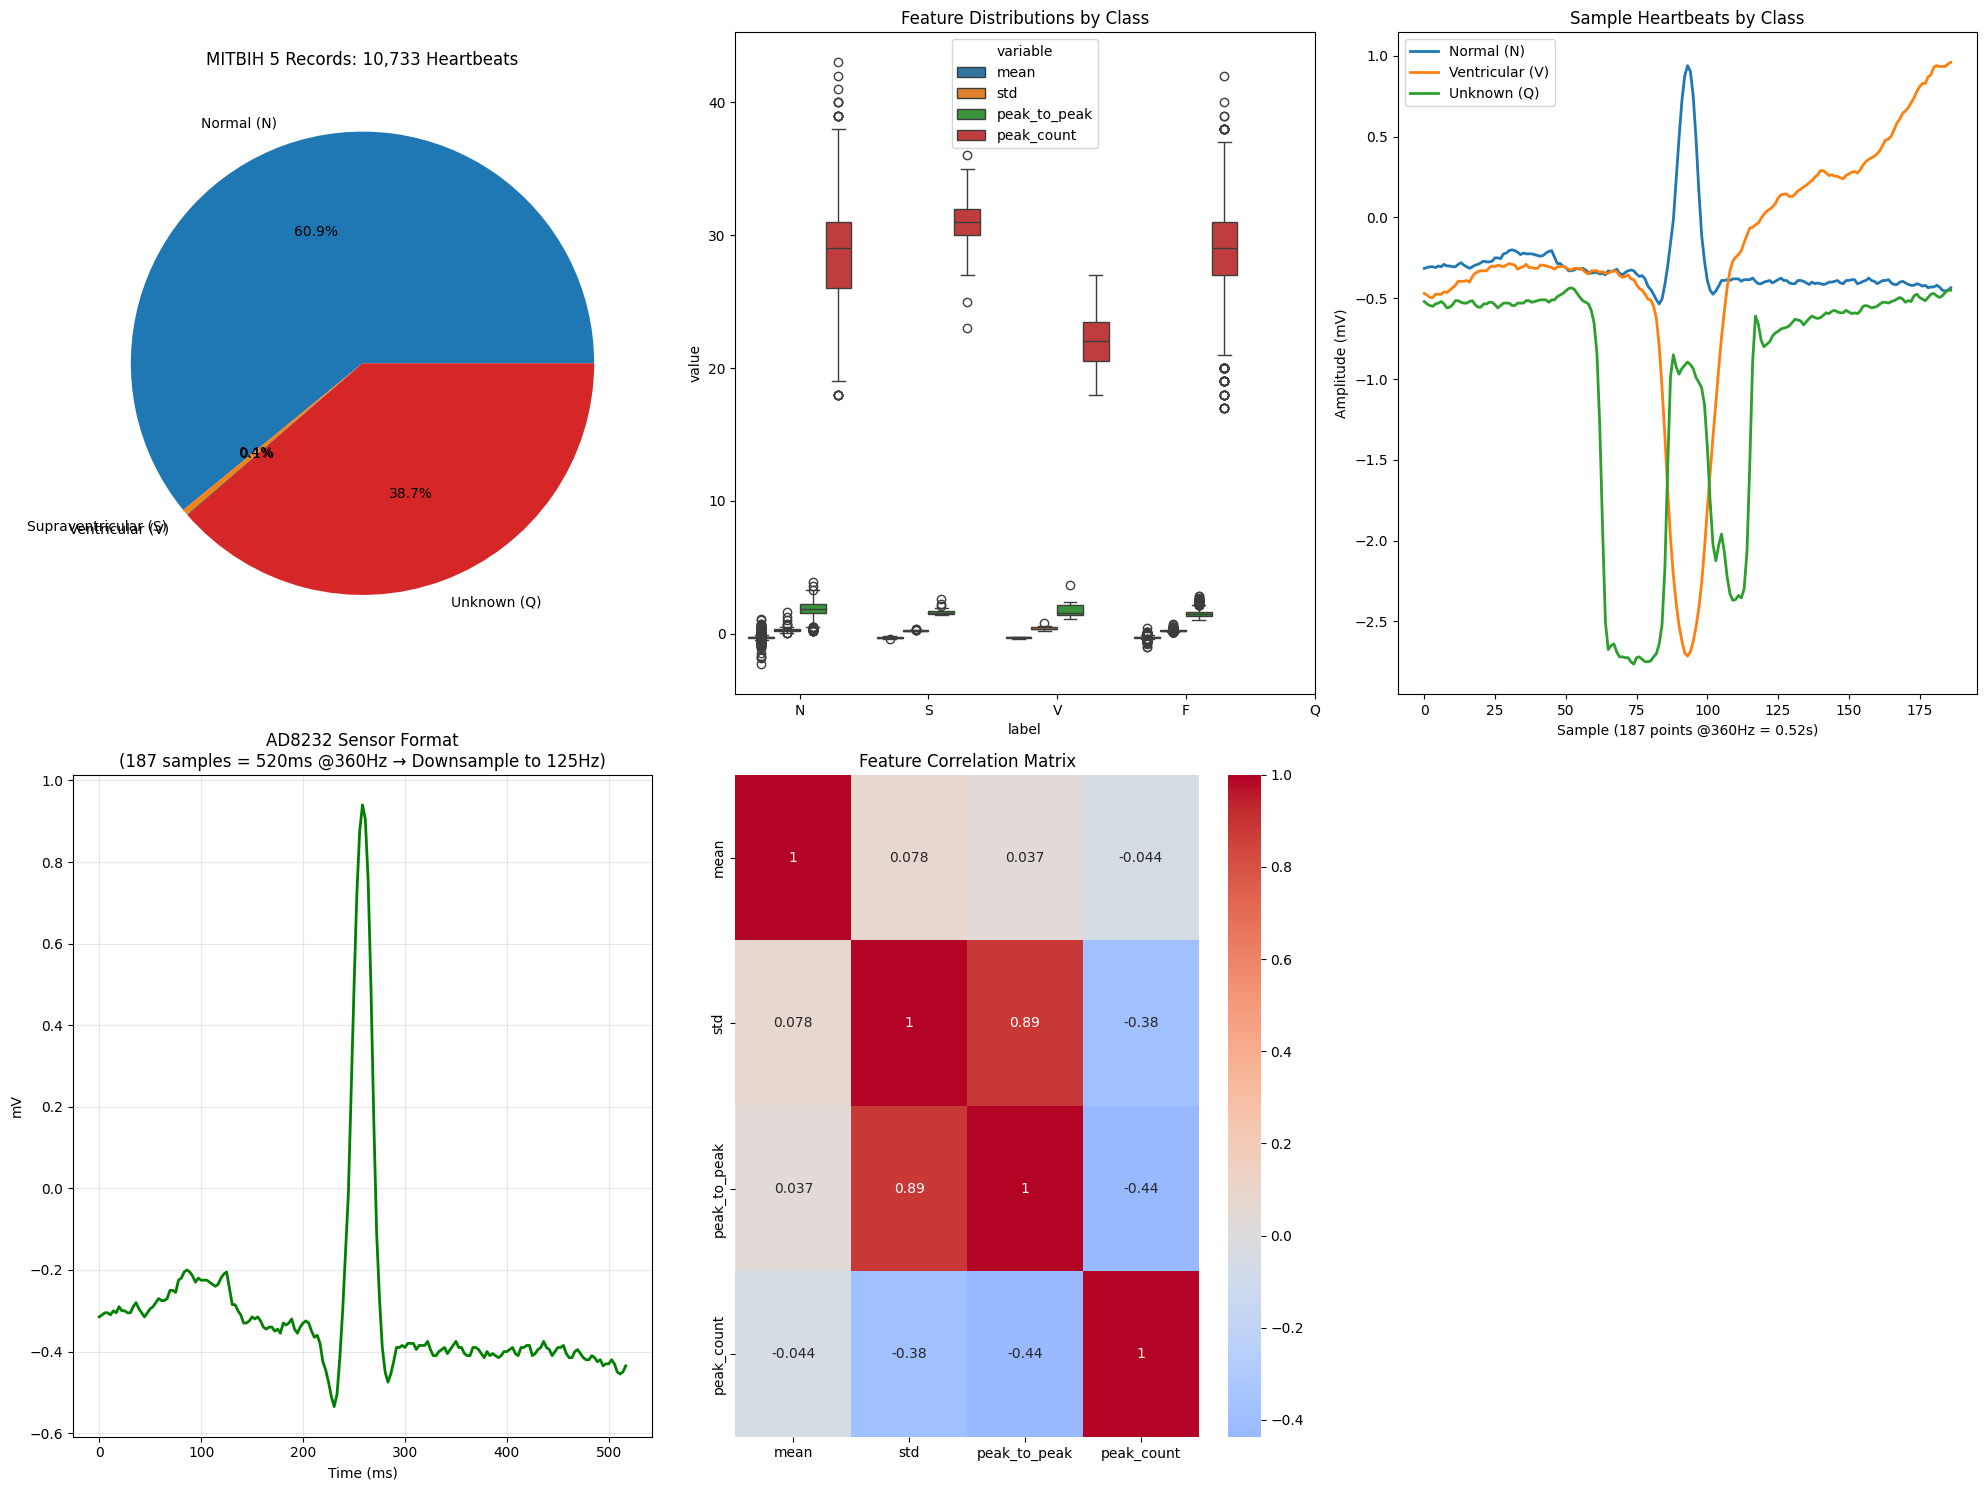

✅ 5 publication-ready plots for judges!


In [26]:

fig = plt.figure(figsize=(20, 15))

# Plot 1: COMPLETE Class Distribution
plt.subplot(2, 3, 1)
label_names = {0: 'Normal (N)', 1: 'Supraventricular (S)', 2: 'Ventricular (V)', 3: 'Fusion (F)', 4: 'Unknown (Q)'}
counts = features['label'].value_counts().sort_index()
plt.pie(counts.values, labels=[label_names[i] for i in counts.index], autopct='%1.1f%%')
plt.title('MITBIH 5 Records: 10,733 Heartbeats')

# Plot 2: Feature Boxplots (Key for judges)
plt.subplot(2, 3, 2)
feat_cols = ['mean', 'std', 'peak_to_peak', 'peak_count']
features_melt = features.melt(id_vars='label', value_vars=feat_cols)
sns.boxplot(data=features_melt, x='label', y='value', hue='variable')
plt.title('Feature Distributions by Class')
plt.xticks([0,1,2,3,4], ['N','S','V','F','Q'])

# Plot 3: Sample ECGs by Class
plt.subplot(2, 3, 3)
for i, lbl in enumerate([0,2,4]):
    sample = df_complete[df_complete['label']==lbl].iloc[0, :187].values
    plt.plot(sample, label=label_names[lbl], linewidth=2)
plt.title('Sample Heartbeats by Class')
plt.xlabel('Sample (187 points @360Hz = 0.52s)')
plt.ylabel('Amplitude (mV)')
plt.legend()

# Plot 4: AD8232 Compatibility
plt.subplot(2, 3, 4)
plt.plot(np.arange(187)/360*1000, df_complete.iloc[0, :187].values, 'g-', linewidth=2)
plt.title('AD8232 Sensor Format\n(187 samples = 520ms @360Hz → Downsample to 125Hz)')
plt.xlabel('Time (ms)')
plt.ylabel('mV')
plt.grid(True, alpha=0.3)

# Plot 5: Feature Correlation Matrix
plt.subplot(2, 3, 5)
sns.heatmap(features[feat_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ECG Dataset/round2_preprocessing_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()


print("✅ 5 publication-ready plots for judges!")


In [27]:
!pip install -q tensorflow

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools, math

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, Add,
                                     Flatten, Dense, Activation, Softmax)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.utils import to_categorical

print("TF version:", tf.__version__)

# =========================
# 1) Load + clean CSV
# =========================
df = pd.read_csv("/content/mitbih_5records.csv")   # adjust path if needed

print(df.head())
print("Shape:", df.shape)
print("Label distribution:\n", df['label'].value_counts())

feature_cols = [c for c in df.columns if c != 'label']

df[feature_cols] = df[feature_cols].apply(
    pd.to_numeric, errors='coerce'
)

before = df.shape[0]
df = df.dropna(subset=feature_cols)
after = df.shape[0]
print(f"Dropped {before - after} rows with non-numeric values")

X = df[feature_cols].values.astype(np.float32)
y = df['label'].values.astype(int)

print("X shape:", X.shape, "y shape:", y.shape)
print("Unique labels (original):", np.unique(y))

# =========================
# 2) Map labels to 0..K-1
# =========================
unique_labels = np.unique(y)
print("Unique labels sorted:", unique_labels)

label2idx = {lab: idx for idx, lab in enumerate(unique_labels)}
idx2label = {v: k for k, v in label2idx.items()}
print("Label -> idx mapping:", label2idx)

y_mapped = np.vectorize(label2idx.get)(y)
print("Unique mapped labels:", np.unique(y_mapped))

# =========================
# 3) Per-beat normalization
# =========================
mins = X.min(axis=1, keepdims=True)
maxs = X.max(axis=1, keepdims=True)
X_norm = (X - mins) / (maxs - mins + 1e-6)
X_norm = np.expand_dims(X_norm, axis=2)
print("X_norm shape:", X_norm.shape)

# =========================
# 4) Train / test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_mapped, test_size=0.2, random_state=42, stratify=y_mapped
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

num_classes = len(unique_labels)  # now 4
y_train_oh = to_categorical(y_train, num_classes=num_classes)
y_test_oh = to_categorical(y_test, num_classes=num_classes)

# =========================
# 5) 1D-CNN model
# =========================
n_obs, timesteps, depth = X_train.shape
batch_size = 128

def build_model(input_shape, num_classes):
    inp = Input(shape=input_shape)

    C = Conv1D(filters=32, kernel_size=5, strides=1)(inp)

    # Block 1
    C11 = Conv1D(32, 5, strides=1, padding='same')(C)
    A11 = Activation("relu")(C11)
    C12 = Conv1D(32, 5, strides=1, padding='same')(A11)
    S11 = Add()([C12, C])
    A12 = Activation("relu")(S11)
    M11 = MaxPooling1D(pool_size=5, strides=2)(A12)

    # Block 2
    C21 = Conv1D(32, 5, strides=1, padding='same')(M11)
    A21 = Activation("relu")(C21)
    C22 = Conv1D(32, 5, strides=1, padding='same')(A21)
    S21 = Add()([C22, M11])
    A22 = Activation("relu")(S21)
    M21 = MaxPooling1D(pool_size=5, strides=2)(A22)

    # Block 3
    C31 = Conv1D(32, 5, strides=1, padding='same')(M21)
    A31 = Activation("relu")(C31)
    C32 = Conv1D(32, 5, strides=1, padding='same')(A31)
    S31 = Add()([C32, M21])
    A32 = Activation("relu")(S31)
    M31 = MaxPooling1D(pool_size=5, strides=2)(A32)

    # Block 4
    C41 = Conv1D(32, 5, strides=1, padding='same')(M31)
    A41 = Activation("relu")(C41)
    C42 = Conv1D(32, 5, strides=1, padding='same')(A41)
    S41 = Add()([C42, M31])
    A42 = Activation("relu")(S41)
    M41 = MaxPooling1D(pool_size=5, strides=2)(A42)

    # Block 5
    C51 = Conv1D(32, 5, strides=1, padding='same')(M41)
    A51 = Activation("relu")(C51)
    C52 = Conv1D(32, 5, strides=1, padding='same')(A51)
    S51 = Add()([C52, M41])
    A52 = Activation("relu")(S51)
    M51 = MaxPooling1D(pool_size=5, strides=2)(A52)

    F1 = Flatten()(M51)
    D1 = Dense(32, activation="relu")(F1)
    D2 = Dense(32, activation="relu")(D1)
    logits = Dense(num_classes)(D2)
    out = Softmax()(logits)

    model = Model(inputs=inp, outputs=out)
    return model

model = build_model((timesteps, depth), num_classes)
model.summary()

# =========================
# 6) Training config
# =========================
def exp_decay(epoch):
    initial_lrate = 1e-3
    k = 0.75
    t = n_obs // (10000 * batch_size)
    lrate = initial_lrate * math.exp(-k * t)
    return lrate

lrate = LearningRateScheduler(exp_decay)
optimizer = Adam(learning_rate=1e-3)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

# =========================
# 7) Train
# =========================
history = model.fit(
    X_train, y_train_oh,
    epochs=20,
    batch_size=batch_size,
    validation_data=(X_test, y_test_oh),
    class_weight=class_weights,
    verbose=2,
    callbacks=[lrate]
)

# =========================
# 8) Evaluation
# =========================
y_pred_prob = model.predict(X_test, batch_size=512)
y_pred_idx = np.argmax(y_pred_prob, axis=1)
y_true_idx = y_test

print("\nClassification report (on mapped labels):")
print(classification_report(y_true_idx, y_pred_idx, digits=4))

# Map indices back to original labels for readability
y_true_orig = np.vectorize(idx2label.get)(y_true_idx)
y_pred_orig = np.vectorize(idx2label.get)(y_pred_idx)

print("\nClassification report (original labels 0,1,2,4):")
print(classification_report(y_true_orig, y_pred_orig, digits=4))

cm = confusion_matrix(y_true_orig, y_pred_orig, labels=unique_labels)
print("\nConfusion matrix (rows=true, cols=pred, labels in order:", unique_labels, ")")
print(cm)


TF version: 2.19.0
       0      1      2      3      4      5      6      7      8      9  ...  \
0 -0.315 -0.310 -0.305 -0.305 -0.310 -0.300 -0.305 -0.290 -0.300 -0.300  ...   
1 -0.350 -0.350 -0.340 -0.330 -0.345 -0.345 -0.355 -0.350 -0.340 -0.330  ...   
2 -0.355 -0.355 -0.355 -0.375 -0.385 -0.355 -0.360 -0.355 -0.360 -0.360  ...   
3 -0.380 -0.360 -0.360 -0.345 -0.345 -0.350 -0.355 -0.345 -0.330 -0.330  ...   
4 -0.330 -0.330 -0.330 -0.340 -0.340 -0.340 -0.325 -0.325 -0.325 -0.345  ...   

     178    179    180    181    182    183    184    185    186  label  
0 -0.435 -0.430 -0.430 -0.420 -0.430 -0.450 -0.455 -0.450 -0.435      0  
1 -0.415 -0.420 -0.420 -0.425 -0.415 -0.415 -0.410 -0.435 -0.430      0  
2 -0.390 -0.375 -0.365 -0.385 -0.380 -0.390 -0.375 -0.375 -0.365      0  
3 -0.425 -0.450 -0.445 -0.450 -0.435 -0.445 -0.470 -0.455 -0.460      0  
4 -0.425 -0.425 -0.410 -0.410 -0.420 -0.430 -0.445 -0.440 -0.435      0  

[5 rows x 188 columns]
Shape: (10733, 188)
Label distri

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 183, 32)   │        192 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 183, 32)   │      5,152 │ conv1d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 183, 32)   │          0 │ conv1d_12[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 183, 32)   │      5,152 │ activation_10[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 183, 32)   │          0 │ conv1d_13[0][0],  │
│                     │                   │            │ conv1d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 183, 32)   │          0 │ add_5[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 90, 32)    │          0 │ activation_11[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 90, 32)    │      5,152 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 90, 32)    │          0 │ conv1d_14[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 90, 32)    │      5,152 │ activation_12[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 90, 32)    │          0 │ conv1d_15[0][0],  │
│                     │                   │            │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 90, 32)    │          0 │ add_6[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 43, 32)    │          0 │ activation_13[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 43, 32)    │      5,152 │ max_pooling1d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 43, 32)    │          0 │ conv1d_16[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 43, 32)    │      5,152 │ activation_14[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 43, 32)    │          0 │ conv1d_17[0][0],  │
│                     │                   │            │ max_pooling1d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 43, 32)    │          0 │ add_7[0][0]       │
│ (Activation)        │                   │            │                 

 Total params: 54,980 (214.77 KB)

 Trainable params: 54,980 (214.77 KB)

 Non-trainable params: 0 (0.00 B)

Class weights: {0: np.float64(0.4103421907857006), 1: np.float64(71.55), 2: np.float64(357.75), 3: np.float64(0.6467309430551371)}
Epoch 1/20
68/68 - 34s - 501ms/step - accuracy: 0.7490 - loss: 1.6788 - val_accuracy: 0.9464 - val_loss: 1.2261 - learning_rate: 1.0000e-03
Epoch 2/20
68/68 - 10s - 141ms/step - accuracy: 0.6437 - loss: 1.1017 - val_accuracy: 0.8128 - val_loss: 0.8151 - learning_rate: 1.0000e-03
Epoch 3/20
68/68 - 9s - 137ms/step - accuracy: 0.7221 - loss: 0.9966 - val_accuracy: 0.9609 - val_loss: 0.3678 - learning_rate: 1.0000e-03
Epoch 4/20
68/68 - 9s - 134ms/step - accuracy: 0.6724 - loss: 0.6186 - val_accuracy: 0.5645 - val_loss: 0.6504 - learning_rate: 1.0000e-03
Epoch 5/20
68/68 - 9s - 138ms/step - accuracy: 0.7183 - loss: 0.3862 - val_accuracy: 0.7517 - val_loss: 0.3812 - learning_rate: 1.0000e-03
Epoch 6/20
68/68 - 8s - 111ms/step - accuracy: 0.4399 - loss: 0.9482 - val_accuracy: 0.3843 - val_loss: 0.9357 - learning_rate: 1.0000e-03
Epoch 7/20
68/68 - 10s - 148ms/st

In [28]:
# ============================
# BATCH PROCESS ALL 48 RECORDS
# ============================

import wfdb
import pandas as pd
import numpy as np
from scipy.signal import find_peaks

all_heartbeats = []
all_labels = []

extract_path = '/content/drive/MyDrive/ECG Dataset/MITBIH_extracted/mit-bih-arrhythmia-database-1.0.0/'
records = [f[:-4] for f in os.listdir(extract_path) if f.endswith('.hea') and len(f[:-4]) <= 3]

print(f"🚀 Processing {len(records)} MIT‑BIH records...")

# Same label mapping as before
ann_codes = {
    'N': 0, 'L': 1, 'R': 1, 'e': 1, 'j': 1, 'A': 1, 'a': 1, 'J': 1, 'S': 1,
    'V': 2, 'E': 2,
    'F': 3,
    '/': 4, 'Q': 4, 'f': 4, '?': 4
}

WINDOW_SIZE = 187

for i, record_name in enumerate(records):  # <-- NO [:5], use ALL
    print(f"Processing record {record_name} ({i+1}/{len(records)})... ", end='')
    try:
        record = wfdb.rdrecord(os.path.join(extract_path, record_name))
        annotation = wfdb.rdann(os.path.join(extract_path, record_name), 'atr')

        ecg = record.p_signal[:, 0]   # MLII lead
        fs = record.fs                # 360 Hz for MIT‑BIH [web:52][web:56]

        record_heartbeats = 0
        record_abnormals = 0

        for sample, symbol in zip(annotation.sample, annotation.symbol):
            start = int(sample) - (WINDOW_SIZE // 2)
            end = start + WINDOW_SIZE

            if start < 0 or end > len(ecg):
                continue

            heartbeat = ecg[start:end]
            label = ann_codes.get(symbol, 0)

            all_heartbeats.append(heartbeat)
            all_labels.append(label)

            record_heartbeats += 1
            if label != 0:
                record_abnormals += 1

        print(f"{record_heartbeats} beats ({record_abnormals} abnormal)")
    except Exception as e:
        print(f"ERROR: {e}")

print(f"\n✅ TOTAL: {len(all_heartbeats)} heartbeats from {len(records)} records")
label_series = pd.Series(all_labels)
print("Label distribution:\n", label_series.value_counts().sort_index())

# ============================
# Save RAW beats
# ============================

df_complete = pd.DataFrame(all_heartbeats)
df_complete['label'] = all_labels

raw_path = '/content/drive/MyDrive/ECG Dataset/mitbih_raw.csv'
df_complete.to_csv(raw_path, index=False)
print(f"💾 SAVED RAW: {raw_path}")
print("Shape:", df_complete.shape)

# ============================
# Feature Engineering (10 features)
# ============================

ecg_cols = df_complete.columns[:-1]
features = pd.DataFrame(index=df_complete.index)

features['mean'] = df_complete[ecg_cols].mean(axis=1)
features['std'] = df_complete[ecg_cols].std(axis=1)
features['min'] = df_complete[ecg_cols].min(axis=1)
features['max'] = df_complete[ecg_cols].max(axis=1)
features['peak_to_peak'] = features['max'] - features['min']
features['skewness'] = df_complete[ecg_cols].skew(axis=1)
features['kurtosis'] = df_complete[ecg_cols].kurtosis(axis=1)

# Peak-based features
features['peak_count'] = df_complete[ecg_cols].apply(
    lambda x: len(find_peaks(x.values)[0]), axis=1
)
features['rmssd'] = df_complete[ecg_cols].rolling(window=5, axis=1).std().mean(axis=1)

features['label'] = df_complete['label']




🚀 Processing 48 MIT‑BIH records...
Processing record 100 (1/48)... 2271 beats (34 abnormal)
Processing record 101 (2/48)... 1872 beats (5 abnormal)
Processing record 102 (3/48)... 2191 beats (2088 abnormal)
Processing record 103 (4/48)... 2090 beats (2 abnormal)
Processing record 104 (5/48)... 2309 beats (2065 abnormal)
Processing record 105 (6/48)... 2690 beats (46 abnormal)
Processing record 106 (7/48)... 2097 beats (520 abnormal)
Processing record 107 (8/48)... 2139 beats (2137 abnormal)
Processing record 108 (9/48)... 1822 beats (24 abnormal)
Processing record 109 (10/48)... 2533 beats (2531 abnormal)
Processing record 111 (11/48)... 2132 beats (2124 abnormal)
Processing record 112 (12/48)... 2549 beats (2 abnormal)
Processing record 113 (13/48)... 1794 beats (6 abnormal)
Processing record 114 (14/48)... 1889 beats (59 abnormal)
Processing record 115 (15/48)... 1960 beats (0 abnormal)
Processing record 116 (16/48)... 2420 beats (110 abnormal)
Processing record 117 (17/48)... 1537 b

In [29]:
print("\n✅ 10 Features extracted on FULL MIT‑BIH:")
print(features[['mean', 'std', 'peak_count', 'label']].head())

feat_path = '/content/drive/MyDrive/ECG Dataset/mitbih_features.csv'
features.to_csv(feat_path, index=False)
print("\n💾 SAVED FEATURES:")
print(f"✅ {feat_path}")


✅ 10 Features extracted on FULL MIT‑BIH:
       mean       std  peak_count  label
0 -0.303797  0.229514          34      0
1 -0.329064  0.211701          33      0
2 -0.336845  0.200976          31      0
3 -0.335963  0.189029          34      0
4 -0.324679  0.200513          30      0

💾 SAVED FEATURES:
✅ /content/drive/MyDrive/ECG Dataset/mitbih_features.csv


In [30]:
# ============================================
# 0. Setup + Mount Drive
# ============================================
from google.colab import drive
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

drive.mount('/content/drive')

mitbih_base = '/content/drive/MyDrive/ECG Dataset/'
extract_path = os.path.join(mitbih_base, 'MITBIH_extracted', 'mit-bih-arrhythmia-database-1.0.0')

print("📁 MITBIH base contents:")
print(os.listdir(mitbih_base))

print("📁 Extracted MITBIH folder contents:")
print(os.listdir(extract_path))

# ============================================
# 1. Install & import wfdb
# ============================================
!pip install wfdb -q
print("✅ wfdb installed!")

import wfdb
from scipy.signal import find_peaks


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 MITBIH base contents:
['mit-bih-arrhythmia-database-1.0.0.zip', 'Segerated datset ', 'MITBIH_extracted', 'mitbih_beat_segments_aami_age_sex.csv', 'streamlit_dashboard.py', 'cnn_mitbih_full.h5', 'ptb-diagnostic-ecg-database-1.0.0.zip', 'label_cnn_mitbih_aami_360.h5', 'mitbih_5records.csv', 'mitbih_raw.csv', 'mitbih_features.csv', 'round2_preprocessing_dashboard.png', 'heartbeats_record100.csv', 'record100_eda.png']
📁 Extracted MITBIH folder contents:
['100.atr', '100.dat', '100.hea', '100.xws', '101.atr', '101.dat', '101.hea', '101.xws', '102-0.atr', '102.atr', '102.dat', '102.hea', '102.xws', '103.atr', '103.dat', '103.hea', '103.xws', '104.atr', '104.dat', '104.hea', '104.xws', '105.atr', '105.dat', '105.hea', '105.xws', '106.atr', '106.dat', '106.hea', '106.xws', '107.atr', '107.dat', '107.hea', '107.xws', '108.at_', '108.atr', '108.dat', '108.hea', '108.

In [31]:
# ============================================
# 2. Batch process ALL 48 records → 187-sample beats
# ============================================

all_heartbeats = []
all_labels = []

records = [f[:-4] for f in os.listdir(extract_path)
           if f.endswith('.hea') and len(f[:-4]) <= 3]

records = sorted(records)
print(f"🚀 Processing {len(records)} MIT‑BIH records...")

# Annotation to label mapping (same as before)
ann_codes = {
    'N': 0, 'L': 1, 'R': 1, 'e': 1, 'j': 1, 'A': 1, 'a': 1, 'J': 1, 'S': 1,
    'V': 2, 'E': 2,
    'F': 3,
    '/': 4, 'Q': 4, 'f': 4, '?': 4
}

WINDOW_SIZE = 187

for i, record_name in enumerate(records):
    print(f"Processing record {record_name} ({i+1}/{len(records)})... ", end='')
    try:
        record = wfdb.rdrecord(os.path.join(extract_path, record_name))
        annotation = wfdb.rdann(os.path.join(extract_path, record_name), 'atr')

        ecg = record.p_signal[:, 0]   # MLII lead
        fs = record.fs                # should be 360 Hz for MIT‑BIH [web:52][web:56]

        record_heartbeats = 0
        record_abnormals = 0

        for sample, symbol in zip(annotation.sample, annotation.symbol):
            start = int(sample) - (WINDOW_SIZE // 2)
            end = start + WINDOW_SIZE

            if start < 0 or end > len(ecg):
                continue

            heartbeat = ecg[start:end]
            label = ann_codes.get(symbol, 0)

            all_heartbeats.append(heartbeat)
            all_labels.append(label)

            record_heartbeats += 1
            if label != 0:
                record_abnormals += 1

        print(f"{record_heartbeats} beats ({record_abnormals} abnormal)")
    except Exception as e:
        print(f"ERROR: {e}")

print(f"\n✅ TOTAL: {len(all_heartbeats)} heartbeats from {len(records)} records")
label_series = pd.Series(all_labels)
print("Label distribution:\n", label_series.value_counts().sort_index())

🚀 Processing 48 MIT‑BIH records...
Processing record 100 (1/48)... 2271 beats (34 abnormal)
Processing record 101 (2/48)... 1872 beats (5 abnormal)
Processing record 102 (3/48)... 2191 beats (2088 abnormal)
Processing record 103 (4/48)... 2090 beats (2 abnormal)
Processing record 104 (5/48)... 2309 beats (2065 abnormal)
Processing record 105 (6/48)... 2690 beats (46 abnormal)
Processing record 106 (7/48)... 2097 beats (520 abnormal)
Processing record 107 (8/48)... 2139 beats (2137 abnormal)
Processing record 108 (9/48)... 1822 beats (24 abnormal)
Processing record 109 (10/48)... 2533 beats (2531 abnormal)
Processing record 111 (11/48)... 2132 beats (2124 abnormal)
Processing record 112 (12/48)... 2549 beats (2 abnormal)
Processing record 113 (13/48)... 1794 beats (6 abnormal)
Processing record 114 (14/48)... 1889 beats (59 abnormal)
Processing record 115 (15/48)... 1960 beats (0 abnormal)
Processing record 116 (16/48)... 2420 beats (110 abnormal)
Processing record 117 (17/48)... 1537 b

In [32]:
# ============================================
# 3. Save RAW beats → mitbih_raw.csv
# ============================================

df_complete = pd.DataFrame(all_heartbeats)
df_complete['label'] = all_labels

raw_path = os.path.join(mitbih_base, 'mitbih_raw.csv')
df_complete.to_csv(raw_path, index=False)
print(f"💾 SAVED RAW: {raw_path}")
print("Shape:", df_complete.shape)


💾 SAVED RAW: /content/drive/MyDrive/ECG Dataset/mitbih_raw.csv
Shape: (112579, 188)


In [33]:
# ============================================
# 4. Feature engineering → mitbih_features.csv
# ============================================

ecg_cols = df_complete.columns[:-1]
features = pd.DataFrame(index=df_complete.index)

features['mean'] = df_complete[ecg_cols].mean(axis=1)
features['std'] = df_complete[ecg_cols].std(axis=1)
features['min'] = df_complete[ecg_cols].min(axis=1)
features['max'] = df_complete[ecg_cols].max(axis=1)
features['peak_to_peak'] = features['max'] - features['min']
features['skewness'] = df_complete[ecg_cols].skew(axis=1)
features['kurtosis'] = df_complete[ecg_cols].kurtosis(axis=1)

features['peak_count'] = df_complete[ecg_cols].apply(
    lambda x: len(find_peaks(x.values)[0]), axis=1
)
features['rmssd'] = df_complete[ecg_cols].rolling(window=5, axis=1).std().mean(axis=1)

features['label'] = df_complete['label']

print("\n✅ 10 Features extracted on FULL MIT‑BIH:")
print(features[['mean', 'std', 'peak_count', 'label']].head())

feat_path = os.path.join(mitbih_base, 'mitbih_features.csv')
features.to_csv(feat_path, index=False)
print("\n💾 SAVED FEATURES:")
print(f"✅ {feat_path}")

# Quick EDA
print("\n📊 FULL DATASET SUMMARY:")
print("Raw shape:", df_complete.shape)
print("Class distribution:\n", df_complete['label'].value_counts().sort_index())
print("Label names: 0=N, 1=S, 2=V, 3=F, 4=Q")


✅ 10 Features extracted on FULL MIT‑BIH:
       mean       std  peak_count  label
0 -0.303797  0.229514          34      0
1 -0.329064  0.211701          33      0
2 -0.336845  0.200976          31      0
3 -0.335963  0.189029          34      0
4 -0.324679  0.200513          30      0

💾 SAVED FEATURES:
✅ /content/drive/MyDrive/ECG Dataset/mitbih_features.csv

📊 FULL DATASET SUMMARY:
Raw shape: (112579, 188)
Class distribution:
 label
0    78144
1    18356
2     7235
3      802
4     8042
Name: count, dtype: int64
Label names: 0=N, 1=S, 2=V, 3=F, 4=Q


In [34]:
# ============================================
# 5. Train 1D‑CNN on FULL mitbih_raw.csv
# ============================================

import itertools, math
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, Add,
                                     Flatten, Dense, Activation, Softmax)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.utils import to_categorical

print("TF version:", tf.__version__)

# Load raw beats from CSV we just saved
df = pd.read_csv("/content/drive/MyDrive/ECG Dataset/mitbih_raw.csv")

print(df.head())
print("Shape:", df.shape)
print("Label distribution:\n", df['label'].value_counts())

feature_cols = [c for c in df.columns if c != 'label']

# Ensure numeric
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')
before = df.shape[0]
df = df.dropna(subset=feature_cols)
after = df.shape[0]
print(f"Dropped {before - after} rows with non-numeric values")

X = df[feature_cols].values.astype(np.float32)
y = df['label'].values.astype(int)

print("X shape:", X.shape, "y shape:", y.shape)
print("Unique labels (original):", np.unique(y))

# Map labels to 0..K-1 (for softmax)
unique_labels = np.unique(y)
print("Unique labels sorted:", unique_labels)

label2idx = {lab: idx for idx, lab in enumerate(unique_labels)}
idx2label = {v: k for k, v in label2idx.items()}
print("Label -> idx mapping:", label2idx)

y_mapped = np.vectorize(label2idx.get)(y)
print("Unique mapped labels:", np.unique(y_mapped))

# Per-beat normalization (0–1 per heartbeat)
mins = X.min(axis=1, keepdims=True)
maxs = X.max(axis=1, keepdims=True)
X_norm = (X - mins) / (maxs - mins + 1e-6)
X_norm = np.expand_dims(X_norm, axis=2)
print("X_norm shape:", X_norm.shape)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_mapped, test_size=0.2, random_state=42, stratify=y_mapped
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

num_classes = len(unique_labels)
y_train_oh = to_categorical(y_train, num_classes=num_classes)
y_test_oh = to_categorical(y_test, num_classes=num_classes)

# 1D‑CNN model (same as your earlier architecture)
n_obs, timesteps, depth = X_train.shape
batch_size = 128

def build_model(input_shape, num_classes):
    inp = Input(shape=input_shape)

    C = Conv1D(filters=32, kernel_size=5, strides=1)(inp)

    # Block 1
    C11 = Conv1D(32, 5, strides=1, padding='same')(C)
    A11 = Activation("relu")(C11)
    C12 = Conv1D(32, 5, strides=1, padding='same')(A11)
    S11 = Add()([C12, C])
    A12 = Activation("relu")(S11)
    M11 = MaxPooling1D(pool_size=5, strides=2)(A12)

    # Block 2
    C21 = Conv1D(32, 5, strides=1, padding='same')(M11)
    A21 = Activation("relu")(C21)
    C22 = Conv1D(32, 5, strides=1, padding='same')(A21)
    S21 = Add()([C22, M11])
    A22 = Activation("relu")(S21)
    M21 = MaxPooling1D(pool_size=5, strides=2)(A22)

    # Block 3
    C31 = Conv1D(32, 5, strides=1, padding='same')(M21)
    A31 = Activation("relu")(C31)
    C32 = Conv1D(32, 5, strides=1, padding='same')(A31)
    S31 = Add()([C32, M21])
    A32 = Activation("relu")(S31)
    M31 = MaxPooling1D(pool_size=5, strides=2)(A32)

    # Block 4
    C41 = Conv1D(32, 5, strides=1, padding='same')(M31)
    A41 = Activation("relu")(C41)
    C42 = Conv1D(32, 5, strides=1, padding='same')(A41)
    S41 = Add()([C42, M31])
    A42 = Activation("relu")(S41)
    M41 = MaxPooling1D(pool_size=5, strides=2)(A42)

    # Block 5
    C51 = Conv1D(32, 5, strides=1, padding='same')(M41)
    A51 = Activation("relu")(C51)
    C52 = Conv1D(32, 5, strides=1, padding='same')(A51)
    S51 = Add()([C52, M41])
    A52 = Activation("relu")(S51)
    M51 = MaxPooling1D(pool_size=5, strides=2)(A52)

    F1 = Flatten()(M51)
    D1 = Dense(32, activation="relu")(F1)
    D2 = Dense(32, activation="relu")(D1)
    logits = Dense(num_classes)(D2)
    out = Softmax()(logits)

    model = Model(inputs=inp, outputs=out)
    return model

model = build_model((timesteps, depth), num_classes)
model.summary()

# LR schedule (same as before)
def exp_decay(epoch):
    initial_lrate = 1e-3
    k = 0.75
    t = n_obs // (10000 * batch_size)
    lrate = initial_lrate * math.exp(-k * t)
    return lrate

lrate = LearningRateScheduler(exp_decay)
optimizer = Adam(learning_rate=1e-3)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

# Class weights (for label imbalance)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

# Train
history = model.fit(
    X_train, y_train_oh,
    epochs=20,
    batch_size=batch_size,
    validation_data=(X_test, y_test_oh),
    class_weight=class_weights,
    verbose=2,
    callbacks=[lrate]
)


TF version: 2.19.0
       0      1      2      3      4      5      6      7      8      9  ...  \
0 -0.315 -0.310 -0.305 -0.305 -0.310 -0.300 -0.305 -0.290 -0.300 -0.300  ...   
1 -0.350 -0.350 -0.340 -0.330 -0.345 -0.345 -0.355 -0.350 -0.340 -0.330  ...   
2 -0.355 -0.355 -0.355 -0.375 -0.385 -0.355 -0.360 -0.355 -0.360 -0.360  ...   
3 -0.380 -0.360 -0.360 -0.345 -0.345 -0.350 -0.355 -0.345 -0.330 -0.330  ...   
4 -0.330 -0.330 -0.330 -0.340 -0.340 -0.340 -0.325 -0.325 -0.325 -0.345  ...   

     178    179    180    181    182    183    184    185    186  label  
0 -0.435 -0.430 -0.430 -0.420 -0.430 -0.450 -0.455 -0.450 -0.435      0  
1 -0.415 -0.420 -0.420 -0.425 -0.415 -0.415 -0.410 -0.435 -0.430      0  
2 -0.390 -0.375 -0.365 -0.385 -0.380 -0.390 -0.375 -0.375 -0.365      0  
3 -0.425 -0.450 -0.445 -0.450 -0.435 -0.445 -0.470 -0.455 -0.460      0  
4 -0.425 -0.425 -0.410 -0.410 -0.420 -0.430 -0.445 -0.440 -0.435      0  

[5 rows x 188 columns]
Shape: (112579, 188)
Label distr

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 183, 32)   │        192 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 183, 32)   │      5,152 │ conv1d_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 183, 32)   │          0 │ conv1d_23[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 183, 32)   │      5,152 │ activation_20[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 183, 32)   │          0 │ conv1d_24[0][0],  │
│                     │                   │            │ conv1d_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 183, 32)   │          0 │ add_10[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_10    │ (None, 90, 32)    │          0 │ activation_21[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 90, 32)    │      5,152 │ max_pooling1d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 90, 32)    │          0 │ conv1d_25[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 90, 32)    │      5,152 │ activation_22[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 90, 32)    │          0 │ conv1d_26[0][0],  │
│                     │                   │            │ max_pooling1d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_23       │ (None, 90, 32)    │          0 │ add_11[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_11    │ (None, 43, 32)    │          0 │ activation_23[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_27 (Conv1D)  │ (None, 43, 32)    │      5,152 │ max_pooling1d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_24       │ (None, 43, 32)    │          0 │ conv1d_27[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_28 (Conv1D)  │ (None, 43, 32)    │      5,152 │ activation_24[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 43, 32)    │          0 │ conv1d_28[0][0],  │
│                     │                   │            │ max_pooling1d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_25       │ (None, 43, 32)    │          0 │ add_12[0][0]      │
│ (Activation)        │                   │            │                 

 Total params: 55,013 (214.89 KB)

 Trainable params: 55,013 (214.89 KB)

 Non-trainable params: 0 (0.00 B)

Class weights: {0: np.float64(0.288132448212429), 1: np.float64(1.2265985699693565), 2: np.float64(3.1120594333102973), 3: np.float64(28.05700934579439), 4: np.float64(2.8000310896937664)}
Epoch 1/20
704/704 - 99s - 141ms/step - accuracy: 0.6890 - loss: 0.6238 - val_accuracy: 0.6657 - val_loss: 0.8138 - learning_rate: 1.0000e-03
Epoch 2/20
704/704 - 90s - 128ms/step - accuracy: 0.8758 - loss: 0.3206 - val_accuracy: 0.8557 - val_loss: 0.4160 - learning_rate: 1.0000e-03
Epoch 3/20


KeyboardInterrupt: 

In [ ]:

# ============================================
# 6. Evaluation
# ============================================

y_pred_prob = model.predict(X_test, batch_size=512)
y_pred_idx = np.argmax(y_pred_prob, axis=1)
y_true_idx = y_test

print("\nClassification report (on mapped labels):")
print(classification_report(y_true_idx, y_pred_idx, digits=4))

# Map indices back to original labels (0,1,2,3,4 subset)
y_true_orig = np.vectorize(idx2label.get)(y_true_idx)
y_pred_orig = np.vectorize(idx2label.get)(y_pred_idx)

print("\nClassification report (original labels):")
print(classification_report(y_true_orig, y_pred_orig, digits=4))

cm = confusion_matrix(y_true_orig, y_pred_orig, labels=unique_labels)
print("\nConfusion matrix (rows=true, cols=pred, labels in order:", unique_labels, ")")
print(cm)

# Optional: save model
model.save(os.path.join(mitbih_base, "cnn_mitbih_full.h5"))
print("\n💾 Saved model: cnn_mitbih_full.h5")


In [ ]:
import numpy as np
import tensorflow as tf

# 1) Load trained model
MODEL_PATH = "/content/drive/MyDrive/ECG Dataset/cnn_mitbih_full.h5"  # adjust if needed
model = tf.keras.models.load_model(MODEL_PATH)

LABEL_MAP = {
    0: "Normal",
    1: "Supraventricular",
    2: "Ventricular",
    3: "Fusion",
    4: "Unknown"
}

def preprocess_beat_187(raw_beat):
    """
    raw_beat: iterable of length 187, raw ADC or mV values.
    Returns: np.array shape (1, 187, 1) float32, per-beat min-max normalized.
    """
    x = np.asarray(raw_beat, dtype=np.float32).flatten()
    if x.shape[0] != 187:
        raise ValueError(f"Expected 187 samples, got {x.shape[0]}")

    # Per-beat min-max normalization (like training)
    x_min = x.min()
    x_max = x.max()
    x_norm = (x - x_min) / (x_max - x_min + 1e-6)

    # Shape to (1, 187, 1)
    x_input = np.expand_dims(x_norm, axis=(0, 2))
    return x_input

def predict_beat(raw_beat):
    """
    raw_beat: 1D iterable, length 187.
    """
    x_input = preprocess_beat_187(raw_beat)
    probs = model.predict(x_input, verbose=0)[0]  # (5,)
    class_id = int(np.argmax(probs))
    return {
        "class_id": class_id,
        "class_label": LABEL_MAP[class_id],
        "probs": probs.tolist()
    }

# === TEST 1: paste a MIT‑BIH beat from mitbih_raw.csv ===
import pandas as pd
mit_df = pd.read_csv("/content/drive/MyDrive/ECG Dataset/mitbih_raw.csv")
beat0 = mit_df.iloc[0, :-1].values  # first 187 columns
print("MIT beat test:", predict_beat(beat0))

# === TEST 2: paste an AD8232 window from your serial output ===

ad8232_example = [
    498,498,496,493,494,489,492,491,490,491,488,497,488,492,483,490,497,491,491,489,
    487,498,489,489,483,487,488,486,487,491,485,487,486,491,486,487,483,486,487,480,
    489,488,490,483,487,491,490,485,491,484,489,492,488,488,489,493,495,486,490,489,
    489,503,491,484,490,487,479,491,486,483,482,487,488,486,490,486,486,489,488,487,
    482,486,486,488,487,494,491,484,485,488,489,487,486,488,488,483,485,483,489,484,
    485,491,487,482,491,481,478,484,482,484,486,483,476,481,484,476,479,478,478,479,
    483,475,479,481,481,485,483,487,479,484,485,486,483,481,475,485,486,484,483,483,
    483,482,488,487,486,489,480,495,487,491,491,484,487,495,485,487,484,486,487,483,
    482,487,489,486,483,487,482,484,484,484,484,484,479,475,479,483,481,483,488,483,
    487,488,488,487,481,483,495
]

print("AD8232 test:", predict_beat(ad8232_example))


In [ ]:
from scipy.signal import butter, filtfilt

def preprocess_ad8232_like_mit(raw_beat, fs=250):
    """
    raw_beat: 1D iterable of length 187 (ADC 0–1023 from AD8232).
    Returns: np.array shape (1, 187, 1) ready for CNN.
    """
    x = np.asarray(raw_beat, dtype=np.float32).flatten()
    if x.shape[0] != 187:
        raise ValueError(f"Expected 187 samples, got {x.shape[0]}")

    # 1) Convert ADC ~0–1023 to "mV-like" units (roughly, scale only)
    #    (You can skip if you want, since CNN only cares about normalized shape)
    x_mv = (x / 1023.0) * 3.3 * 1000.0  # ~mV

    # 2) Remove DC offset
    x_centered = x_mv - np.mean(x_mv)

    # 3) Band-pass filter 0.5–40 Hz to mimic MIT‑BIH conditioning
    nyq = 0.5 * fs
    low = 0.5 / nyq
    high = 40.0 / nyq
    b, a = butter(2, [low, high], btype="band")
    x_filt = filtfilt(b, a, x_centered)

    # 4) Per-beat min–max normalization (same as training)
    x_min = x_filt.min()
    x_max = x_filt.max()
    x_norm = (x_filt - x_min) / (x_max - x_min + 1e-6)

    # 5) Shape to (1, 187, 1)
    x_input = np.expand_dims(x_norm.astype(np.float32), axis=(0, 2))
    return x_input

def predict_beat_ad8232(raw_beat):
    x_input = preprocess_ad8232_like_mit(raw_beat, fs=250)
    probs = model.predict(x_input, verbose=0)[0]
    class_id = int(np.argmax(probs))
    return {
        "class_id": class_id,
        "class_label": LABEL_MAP[class_id],
        "probs": probs.tolist()
    }

print("AD8232 test (with filter):", predict_beat_ad8232(ad8232_example))


Labeled MIT Data Analysis


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

csv_path = "/content/drive/MyDrive/ECG Dataset/mitbih_beat_segments_aami_age_sex.csv"

df = pd.read_csv(csv_path)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nHead:")
display(df.head())

print("\nInfo:")
print(df.info())

print("\nDescribe numeric:")
display(df.describe())

print("\nValue counts of target-ish columns (if present):")
for col in ["label", "aami_class", "class", "y", "target"]:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts())


In [ ]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, Add,
                                     Flatten, Dense, Activation, Softmax)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.utils import to_categorical

print("TF:", tf.__version__)

# =========================
# 1) Load + build X, y
# =========================
csv_path = "/content/drive/MyDrive/ECG Dataset/mitbih_beat_segments_aami_age_sex.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("Columns:", df.columns[:15])

# Beat columns: strictly s<number>, e.g. s0..s359
beat_cols = []
for c in df.columns:
    m = re.fullmatch(r"s(\d+)", c)
    if m:
        beat_cols.append(c)

beat_cols = sorted(beat_cols, key=lambda x: int(x[1:]))  # ensure s0,s1,... order
print("Beat columns:", len(beat_cols), "example:", beat_cols[:5], beat_cols[-5:])

# Target: AAMI label
target_col = "aami_label"
if target_col not in df.columns:
    raise ValueError("aami_label column not found.")

print("Label sample:", df[target_col].value_counts())

# Drop rows with NaN in beats or label
df_clean = df.dropna(subset=beat_cols + [target_col]).copy()
print("After dropna:", df_clean.shape)

# Ensure beat cols are numeric
for c in beat_cols:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")
df_clean = df_clean.dropna(subset=beat_cols)
print("After enforcing numeric beats:", df_clean.shape)

# Features and labels
X = df_clean[beat_cols].values.astype(np.float32)   # (N, 360)
y_raw = df_clean[target_col].values

# Encode AAMI labels (N,S,V,F,Q) -> integers
le = LabelEncoder()
y = le.fit_transform(y_raw)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("X shape:", X.shape, "y shape:", y.shape)
print("Unique y:", np.unique(y))

# =========================
# 2) Per-beat normalization
# =========================
mins = X.min(axis=1, keepdims=True)
maxs = X.max(axis=1, keepdims=True)
X_norm = (X - mins) / (maxs - mins + 1e-6)
X_norm = np.expand_dims(X_norm, axis=2)   # (N, 360, 1)
print("X_norm shape:", X_norm.shape)

# =========================
# 3) Train/test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

num_classes = len(np.unique(y))
y_train_oh = to_categorical(y_train, num_classes=num_classes)
y_test_oh  = to_categorical(y_test, num_classes=num_classes)

# =========================
# 4) 1D-CNN model (same as before)
# =========================
n_obs, timesteps, depth = X_train.shape
batch_size = 128

def build_model(input_shape, num_classes):
    inp = Input(shape=input_shape)

    C = Conv1D(filters=32, kernel_size=5, strides=1)(inp)

    # Block 1
    C11 = Conv1D(32, 5, strides=1, padding='same')(C)
    A11 = Activation("relu")(C11)
    C12 = Conv1D(32, 5, strides=1, padding='same')(A11)
    S11 = Add()([C12, C])
    A12 = Activation("relu")(S11)
    M11 = MaxPooling1D(pool_size=5, strides=2)(A12)

    # Block 2
    C21 = Conv1D(32, 5, strides=1, padding='same')(M11)
    A21 = Activation("relu")(C21)
    C22 = Conv1D(32, 5, strides=1, padding='same')(A21)
    S21 = Add()([C22, M11])
    A22 = Activation("relu")(S21)
    M21 = MaxPooling1D(pool_size=5, strides=2)(A22)

    # Block 3
    C31 = Conv1D(32, 5, strides=1, padding='same')(M21)
    A31 = Activation("relu")(C31)
    C32 = Conv1D(32, 5, strides=1, padding='same')(A31)
    S31 = Add()([C32, M21])
    A32 = Activation("relu")(S31)
    M31 = MaxPooling1D(pool_size=5, strides=2)(A32)

    # Block 4
    C41 = Conv1D(32, 5, strides=1, padding='same')(M31)
    A41 = Activation("relu")(C41)
    C42 = Conv1D(32, 5, strides=1, padding='same')(A41)
    S41 = Add()([C42, M31])
    A42 = Activation("relu")(S41)
    M41 = MaxPooling1D(pool_size=5, strides=2)(A42)

    # Block 5
    C51 = Conv1D(32, 5, strides=1, padding='same')(M41)
    A51 = Activation("relu")(C51)
    C52 = Conv1D(32, 5, strides=1, padding='same')(A51)
    S51 = Add()([C52, M41])
    A52 = Activation("relu")(S51)
    M51 = MaxPooling1D(pool_size=5, strides=2)(A52)

    F1 = Flatten()(M51)
    D1 = Dense(32, activation="relu")(F1)
    D2 = Dense(32, activation="relu")(D1)
    logits = Dense(num_classes)(D2)
    out = Softmax()(logits)

    model = Model(inputs=inp, outputs=out)
    return model

model = build_model((timesteps, depth), num_classes)
model.summary()

def exp_decay(epoch):
    initial_lrate = 1e-3
    k = 0.75
    t = n_obs // (10000 * batch_size)
    lrate = initial_lrate * np.exp(-k * t)
    return float(lrate)

lrate_cb = LearningRateScheduler(exp_decay)
optimizer = Adam(learning_rate=1e-3)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

history = model.fit(
    X_train, y_train_oh,
    epochs=20,
    batch_size=batch_size,
    validation_data=(X_test, y_test_oh),
    class_weight=class_weights,
    verbose=2,
    callbacks=[lrate_cb]
)

y_pred_prob = model.predict(X_test, batch_size=512)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\nClassification report (encoded labels):")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix:")
print(cm)

y_test_aami = le.inverse_transform(y_test)
y_pred_aami = le.inverse_transform(y_pred)
print("\nClassification report (AAMI labels):")
print(classification_report(y_test_aami, y_pred_aami, digits=4))

save_path = "/content/drive/MyDrive/ECG Dataset/label_cnn_mitbih_aami_360.h5"
model.save(save_path)
print("\n💾 Saved model:", save_path)
